In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import root_scalar

In [2]:
from baxter_method import log_Q, log_Q_all
from propagator import (p_funcs_zeta_1, p_funcs_lambda, p_funcs_gamma,
                        p_funcs_k1, factor_calc_T, factor_calc_H, get_b_val)
from physics import energy_2d as energy

In [3]:
def _compute_estimators_worker_fd_single(tau_mid, tau_step, n, N, w):
    tau_1 = tau_mid - 0.5 * tau_step
    tau_2 = tau_mid + 0.5 * tau_step
    
    epsilon = tau_mid / N
    eps_s = w * epsilon
    
    lambda_val = p_funcs_lambda(epsilon)
    gamma_val = p_funcs_gamma(epsilon)
    
    lambda_val_s = p_funcs_lambda(eps_s)
    zeta_1_s = p_funcs_zeta_1(eps_s)
    k1_s = p_funcs_k1(eps_s)
    
    gamma_val_s = math.sqrt(max(0, zeta_1_s**2 - 1.0)) / k1_s
    
    fT_reg, fT_star = factor_calc_T(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s)
    fH_reg, fH_star = factor_calc_H(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s)
    
    def fd_log_Q(num_particles, b1, b2):
        lq1 = log_Q(num_particles, b1)
        lq2 = log_Q(num_particles, b2)
        return (lq1 - lq2) / tau_step
        
    def fd_log_Q_all(num_particles, b1, b2):
        lq1 = log_Q_all(num_particles, b1)
        lq2 = log_Q_all(num_particles, b2)
        return (lq1 - lq2) / tau_step

    def get_b_val(tau_val, N_val, w_val):
        eps = w_val * (tau_val / N_val)
        z1 = p_funcs_zeta_1(eps)
        u = math.acosh(z1) if z1 >= 1.0 else 0.0
        return math.exp(-N_val * u)
        
    b_tau1 = get_b_val(tau_1, N, 1.0)
    b_tau2 = get_b_val(tau_2, N, 1.0)
    
    b_s_tau1 = get_b_val(tau_1, N, w)
    b_s_tau2 = get_b_val(tau_2, N, w)

    energy1_T = fd_log_Q(1, b_tau1, b_tau2)
    energystar_T_all = fd_log_Q_all(n, b_s_tau1, b_s_tau2) 
    energy1star_T = energystar_T_all[1]
    
    energy1_H = energy1_T * (fH_reg / fT_reg)
    energystar_diff_H_all = (energystar_T_all - energy1star_T) * (fH_star / fT_star)
    energy_H_all = energy1_H + energystar_diff_H_all
    
    # Return energy_H_all[1:] so it has shape (n,) with n=1 at index 0
    return energy_H_all[1:]


In [4]:
from physics import get_Cv_TF

def get_Cv_H(tau_mid, max_n, N, w):
    tau_step = 0.05
    dtau = 0.01
    tau1 = tau_mid - dtau / 2
    tau2 = tau_mid + dtau / 2
    E1 = _compute_estimators_worker_fd_single(tau1, tau_step, max_n, N, w)
    E2 = _compute_estimators_worker_fd_single(tau2, tau_step, max_n, N, w)
    return -(tau_mid**2) * (E2 - E1) / dtau


In [5]:
def generate_heatmap_data(T_vals, max_n=1000, max_N=256):
    w = 1.0
    tau_step = 0.05
    n_vals = np.arange(1, max_n + 1)
    
    N_search_list = list(range(2, 258, 2))
    heatmap_N = np.zeros((len(n_vals), len(T_vals)), dtype=int)
    
    for j, T in enumerate(T_vals):
        print(f"Processing T = {T:.2f} ({j+1}/{len(T_vals)})...")
        tau_mid = 1.0 / T
        
        # 1. Calculate TF Heat Capacity array
        # Compute individually for all n to avoid interpolation artifacts
        Cv_TF_arr = np.zeros(len(n_vals))
        for i, n in enumerate(n_vals):
            Cv_TF_arr[i] = get_Cv_TF(n, T)
            
        # 2. Calculate Exact Heat Capacity array (N=256)
        print("  Computing exact (N=256) array...")
        Cv_exact_arr = get_Cv_H(tau_mid, max_n, 256, w)
        
        # 3. Calculate Threshold Array
        dev_TF = np.abs(Cv_TF_arr - Cv_exact_arr)
        threshold_arr = dev_TF
        
        # We process N incrementally until all n's satisfy the condition
        # If N condition satisfied, store it
        unsatisfied_indices = np.arange(max_n)
        
        for N in N_search_list:
            if len(unsatisfied_indices) == 0:
                break
            
            # We don't need to recompute for N=256 if we reach it
            if N == 256:
                heatmap_N[unsatisfied_indices, j] = 256
                break
                
            Cv_N_arr = get_Cv_H(tau_mid, max_n, N, w)
            
            dev_N = np.abs(Cv_N_arr[unsatisfied_indices] - Cv_exact_arr[unsatisfied_indices])
            tol = threshold_arr[unsatisfied_indices]
            
            satisfied_mask = dev_N <= tol
            newly_satisfied = unsatisfied_indices[satisfied_mask]
            
            heatmap_N[newly_satisfied, j] = N
            unsatisfied_indices = unsatisfied_indices[~satisfied_mask]
            
    return heatmap_N


In [6]:
T_vals = np.linspace(0.05, 0.5, 100)

In [7]:

max_n = 500
heatmap_N = generate_heatmap_data(T_vals, max_n=max_n)
np.save("Saved_runs_and_plots/heatmap_data_C_wiggles.npy", heatmap_N)

Processing T = 0.05 (1/100)...
  Computing exact (N=256) array...
Processing T = 0.05 (2/100)...
  Computing exact (N=256) array...
Processing T = 0.06 (3/100)...
  Computing exact (N=256) array...
Processing T = 0.06 (4/100)...
  Computing exact (N=256) array...
Processing T = 0.07 (5/100)...
  Computing exact (N=256) array...
Processing T = 0.07 (6/100)...
  Computing exact (N=256) array...
Processing T = 0.08 (7/100)...
  Computing exact (N=256) array...
Processing T = 0.08 (8/100)...
  Computing exact (N=256) array...
Processing T = 0.09 (9/100)...
  Computing exact (N=256) array...
Processing T = 0.09 (10/100)...
  Computing exact (N=256) array...
Processing T = 0.10 (11/100)...
  Computing exact (N=256) array...
Processing T = 0.10 (12/100)...
  Computing exact (N=256) array...
Processing T = 0.10 (13/100)...
  Computing exact (N=256) array...
Processing T = 0.11 (14/100)...
  Computing exact (N=256) array...
Processing T = 0.11 (15/100)...
  Computing exact (N=256) array...
Proc

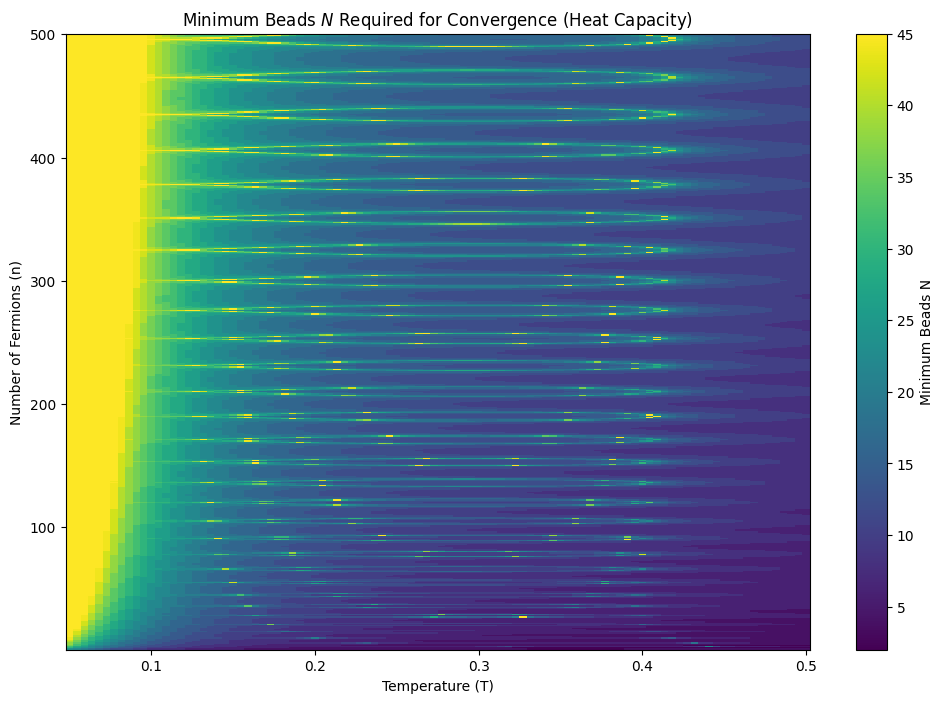

In [9]:
heatmap_N = np.load("Saved_runs_and_plots/heatmap_data_C_wiggles.npy")

plt.figure(figsize=(12, 8))

# FIX: Create n_vals to exactly match the number of rows in heatmap_N
n_vals = np.arange(1, heatmap_N.shape[0] + 1) 

# Calculate your max value
max_val = 45#np.max(heatmap_N[heatmap_N < 256]) if np.any(heatmap_N < 256) else 256

# Now that T_vals (128), n_vals (1000), and heatmap_N (1000, 128) all align, 
# pcolormesh will successfully map them using shading='auto'
mesh = plt.pcolormesh(T_vals, n_vals, heatmap_N, cmap='viridis', vmax=max_val, shading='auto')

# Add the colorbar 
plt.colorbar(mesh, label='Minimum Beads N')

# Set X to log scale
#plt.xscale('log')

# Formatting
plt.xlabel("Temperature (T)")
plt.ylabel("Number of Fermions (n)")
plt.title(r"Minimum Beads $N$ Required for Convergence (Heat Capacity)")

plt.show()